In [1]:
import alphashape
import geopandas as gpd
import laspy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN

In [2]:
laz_path = "../data/tuile_1.laz"
las = laspy.read(laz_path)

x = las.x
y = las.y
z = las.z

classes = np.array(las.classification)

In [3]:
buildings = classes == 6

x_buildings = x[buildings]
y_buildings = y[buildings]
z_buildings = z[buildings]

print('Nombre de points batiments : ', len(x_buildings))

Nombre de points batiments :  3416815


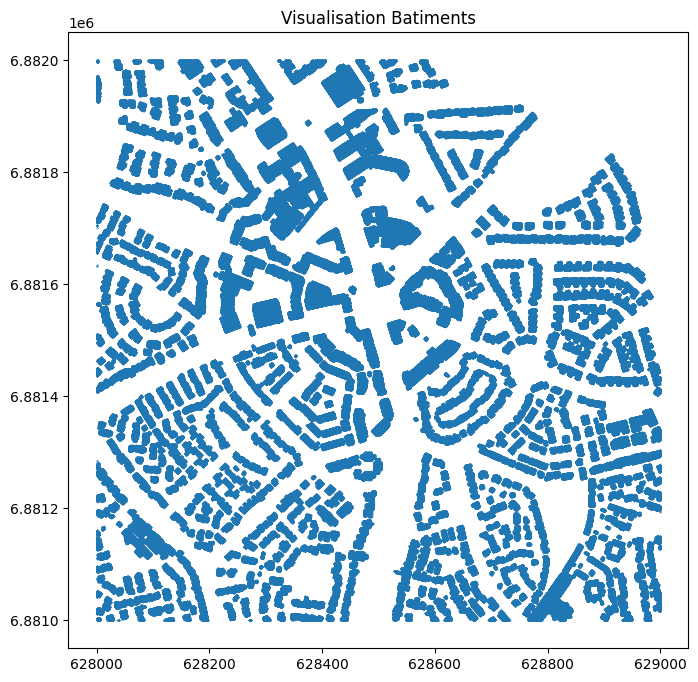

In [4]:
plt.figure(figsize=(8, 8))
plt.scatter(x_buildings, y_buildings, s=0.01)
plt.title("Visualisation Batiments")
plt.show()

In [5]:
xy_buildings = np.column_stack([x_buildings, y_buildings])

cluster = DBSCAN(
    eps=0.7,
    min_samples=10,
    # La calibration est faite à la main
).fit(xy_buildings)

In [6]:
labels = cluster.labels_
unique_labels = np.unique(labels)
n_clusters = np.sum(unique_labels != -1)
n_noise = np.sum(labels == -1)

print('Nombre de clusters batiments : ', n_clusters)
print('Nombre de points bruit : ', n_noise)

Nombre de clusters batiments :  1101
Nombre de points bruit :  253


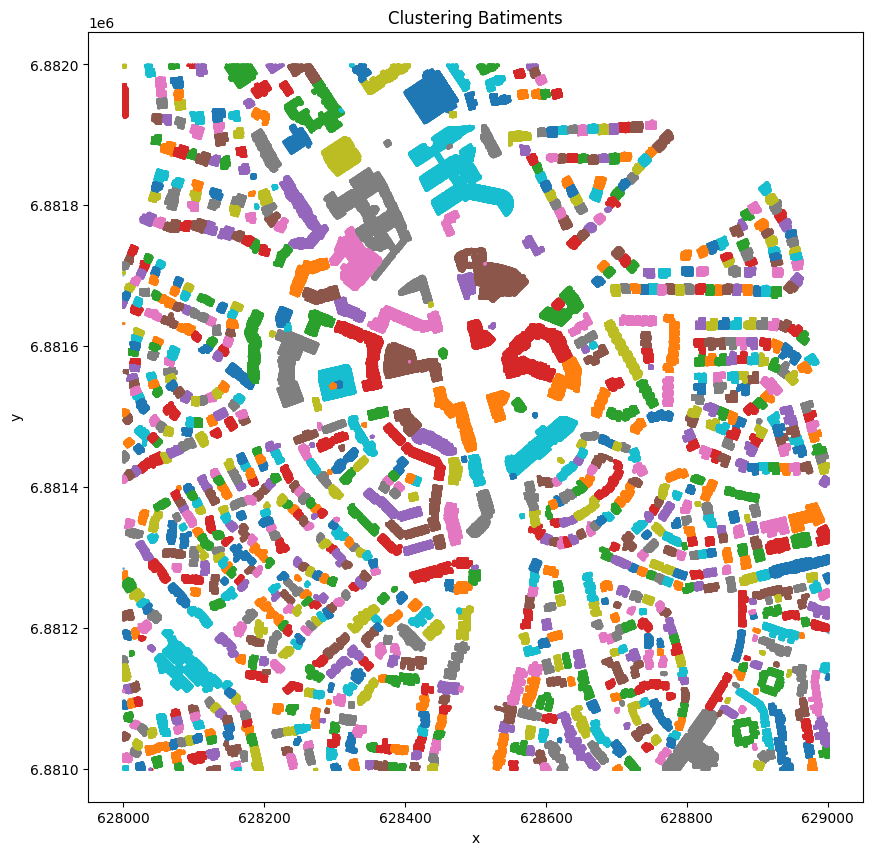

In [7]:
plt.figure(figsize=(10, 10))

for label in unique_labels:
    mask = labels == label
    if label == -1:
        plt.scatter(x_buildings[mask], y_buildings[mask], s=0.2, alpha=0.2, label="bruit")
    else:
        plt.scatter(x_buildings[mask], y_buildings[mask], s=0.4)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Clustering Batiments')
plt.axis('equal')
plt.show()


In [8]:
emprises = []
emprises_id = []
emprises_nb_pts = []

for label in unique_labels:

    if label == -1:
        continue

    mask = labels == label
    nb_pts = np.sum(mask)

    if nb_pts < 100:  # Disons qu'un cluster de moins de 100 points n'est pas un batiment mais du bruit mal catégorisé
        continue

    x_emprise = x_buildings[mask]
    y_emprise = y_buildings[mask]
    xy_emprise = np.column_stack([x_emprise, y_emprise])

    geom = alphashape.alphashape(xy_emprise, alpha=0.5)

    emprises.append(geom)
    emprises_id.append(int(label))
    emprises_nb_pts.append(int(nb_pts))

print("Nombre d'emprises batiments : ", len(emprises))


Nombre d'emprises batiments :  1091


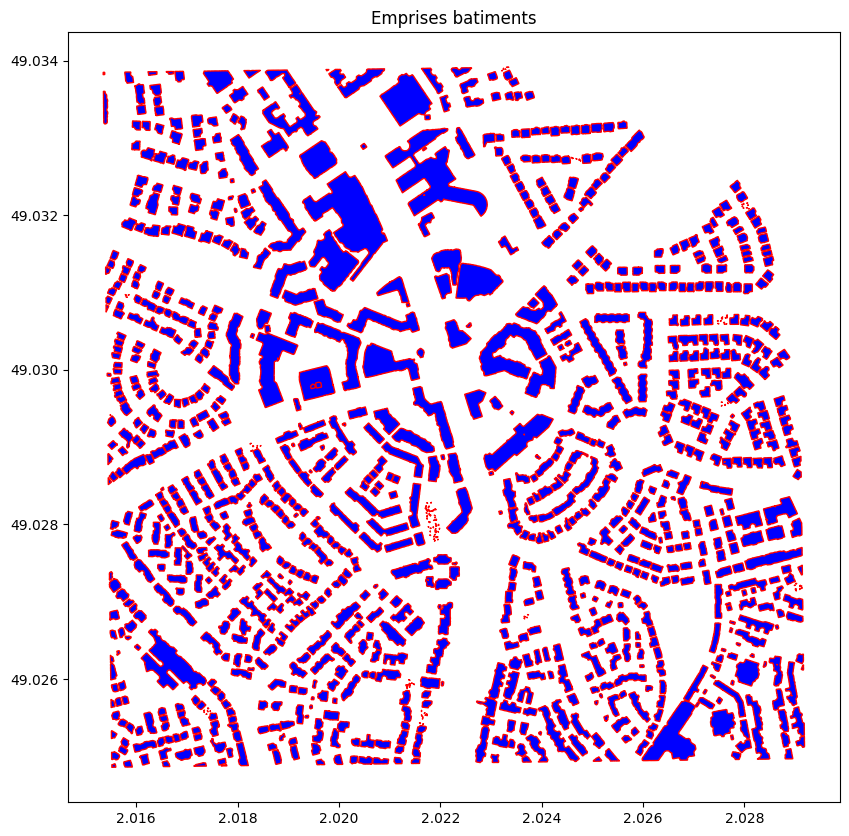

In [9]:
geojson = gpd.GeoDataFrame(
    {
        "building_id": emprises_id,
        "n_points": emprises_id,
    },
    geometry=emprises,
    crs=las.header.parse_crs()
)

geojson = geojson.to_crs("EPSG:4326")

ax = geojson.plot(figsize=(10, 10), edgecolor='red', facecolor='blue')
ax.set_title('Emprises batiments')
plt.show()

In [10]:
geojson_path = "../outputs/buildings_emprises_2.geojson"
geojson.to_file(geojson_path, driver='GeoJSON')

print("GeoJSON écrit :", geojson_path)


GeoJSON écrit : ../outputs/buildings_emprises_2.geojson
